
# 动画图片线稿提取与融合 Notebook

这个 Notebook 包含四部分：

1. **Photocopy 灰度线稿**：更忠实于原图结构  
2. **Anime2Sketch 结果读取**：读取你已部署好的 anime2sketch 输出  
3. **三种融合策略**：透明度叠加 / 最小值融合 / 结构 mask 融合  
4. **参数预览与保存**：方便你快速比较最终效果



In [1]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False



## 1. 路径与基础参数


- `image_path`：原图
- `anime_path`：anime2sketch 的输出图（如果你已经跑好）
- `out_dir`：结果保存目录


In [3]:
img_path = "imass.png"  # TODO:
img_path = str(img_path)

img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"not found:{img_path}")


# ===== 路径配置 =====
image_path = "imas.png"                  # 原图路径
anime_path = "imas_a2s.png"   # anime2sketch输出路径（若已生成）
out_dir = Path("lineart_outputs")
out_dir.mkdir(exist_ok=True)

# ===== Photocopy 参数（推荐起点：赛璐璐上色干净）=====
detail = 4               # 推荐 3~6；越大线越少
darkness = 18            # 推荐 10~28；越大整体越暗
gamma = 0.72             # 推荐 0.60~0.85；越小越保留细线
soft_thr = 0.34          # 推荐 0.28~0.42；越大越去灰区域
soft_keep = 0.22         # 低于阈值区域保留比例，越小越干净
contrast_alpha = 1.45    # 最终对比度增强
contrast_beta = -22      # 最终亮度偏移（负值使灰区更白）

# ===== 结构细化参数 =====
thin_method = "erode"    # "none" / "erode" / "skeleton"
erode_kernel = 2         # 1~3
erode_iter = 1           # 1~2

# ===== 融合参数 =====
blend_alpha = 0.60       # structure透明度
blend_beta = 0.40        # style透明度
mask_blur = 3            # 结构mask轻微平滑



## 2. 工具函数


In [4]:

def read_gray(image_path: str):
    img = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"无法读取图片: {image_path}")
    if img.ndim == 3:
        if img.shape[2] == 4:
            img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img.copy()
    return gray

def show_images(images, titles=None, cmap="gray", cols=3, figsize=(14, 8)):
    n = len(images)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=figsize)
    for i, img in enumerate(images, 1):
        plt.subplot(rows, cols, i)
        plt.imshow(img, cmap=cmap)
        plt.axis("off")
        if titles:
            plt.title(titles[i-1])
    plt.tight_layout()
    plt.show()

def invert_gray(img_u8):
    return 255 - img_u8

def thinning_fallback(binary_black_on_white):
    """
    输入: 黑线白底二值图
    输出: 黑线白底细化图
    """
    line_mask = (binary_black_on_white == 0).astype(np.uint8)

    thinned = None
    if hasattr(cv2, "ximgproc") and hasattr(cv2.ximgproc, "thinning"):
        th = cv2.ximgproc.thinning(line_mask * 255, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
        thinned = (th > 0).astype(np.uint8)
    else:
        try:
            from skimage.morphology import skeletonize
            th = skeletonize(line_mask > 0)
            thinned = th.astype(np.uint8)
        except Exception:
            thinned = line_mask

    out = np.where(thinned > 0, 0, 255).astype(np.uint8)
    return out

def make_blackline_whitebg(gray_line):
    """
    把任意灰度线稿转成“黑线白底”的方向。
    简单策略：如果整体偏暗，反相。
    """
    m = gray_line.mean()
    return invert_gray(gray_line) if m < 127 else gray_line



## 3. 改进版 Photocopy 灰度线稿

这一版针对你的需求做了三点增强：

1. **更小的 blur 半径**，保留更多细线  
2. **gamma 压缩**，增强线条响应  
3. **soft threshold**，尽可能去除灰色区域但不直接硬二值化


In [5]:

def photocopy_gray_lineart(
    image_path,
    detail=4,
    darkness=18,
    gamma=0.72,
    soft_thr=0.34,
    soft_keep=0.22,
    contrast_alpha=1.45,
    contrast_beta=-22,
):
    gray = read_gray(image_path)

    # 0~1 归一化
    gray_norm = gray.astype(np.float32) / 255.0

    # Photocopy 主体
    inverted = 1.0 - gray_norm

    # blur 半径建议比原版更小，以保留更多线
    blur_radius = max(0.6, detail * 0.3)
    kernel_size = int(blur_radius * 2) * 2 + 1
    blurred = cv2.GaussianBlur(inverted, (kernel_size, kernel_size), blur_radius)

    blurred_inverted = 1.0 - blurred

    # Color Dodge
    dodge = gray_norm / (blurred_inverted + 1e-7)
    dodge = np.clip(dodge, 0, 1)

    # darkness
    darkness_factor = 1.0 - (darkness / 100.0)
    result = dodge * darkness_factor

    # gamma：<1 保留更多细线
    result = np.power(np.clip(result, 0, 1), gamma)

    # 归一化，压缩灰色区域
    result = cv2.normalize(result, None, 0, 1, cv2.NORM_MINMAX)

    # soft threshold：减少灰色区域，但不完全二值化
    low_mask = result < soft_thr
    result[low_mask] *= soft_keep

    # 转 uint8 + 对比增强
    result_u8 = (np.clip(result, 0, 1) * 255).astype(np.uint8)
    result_u8 = cv2.convertScaleAbs(result_u8, alpha=contrast_alpha, beta=contrast_beta)

    # 保证方向为黑线白底
    result_u8 = make_blackline_whitebg(result_u8)

    steps = {
        "gray": gray,
        "inverted": (inverted * 255).astype(np.uint8),
        "blurred_inverted": (blurred_inverted * 255).astype(np.uint8),
        "dodge": (dodge * 255).astype(np.uint8),
        "photocopy_gray": result_u8,
    }
    return result_u8, steps



## 4. 可选：让结构线更细，并反转颜色

如果你觉得 `B_binary` 或结构线已经不错，但偏粗，可以：

- `erode`：简单细化  
- `skeleton`：骨架化，线会更细更统一  
- `invert`：颜色反转


In [6]:

def thin_structure_line(line_black_on_white, method="erode", erode_kernel=2, erode_iter=1):
    out = line_black_on_white.copy()

    if method == "none":
        return out

    if method == "erode":
        # 为了腐蚀黑线，先反相成白线黑底
        inv = 255 - out
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (erode_kernel, erode_kernel))
        inv = cv2.erode(inv, kernel, iterations=erode_iter)
        out = 255 - inv
        return out

    if method == "skeleton":
        # 先做轻度二值化再骨架化
        _, bw = cv2.threshold(out, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        bw = make_blackline_whitebg(bw)
        return thinning_fallback(bw)

    raise ValueError("method 只能是 none / erode / skeleton")

def invert_output(img_u8):
    return 255 - img_u8



## 5. 运行 Photocopy，并查看中间结果


/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 28784 (\N{CJK UNIFIED IDEOGRAPH-7070}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 21709 (\N{CJK UNIFIED IDEOGRAPH-54CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 24212 (\N{CJK UNIFIED IDEOGRAPH-5E94}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 32447 (\N{CJK UNIFIED I

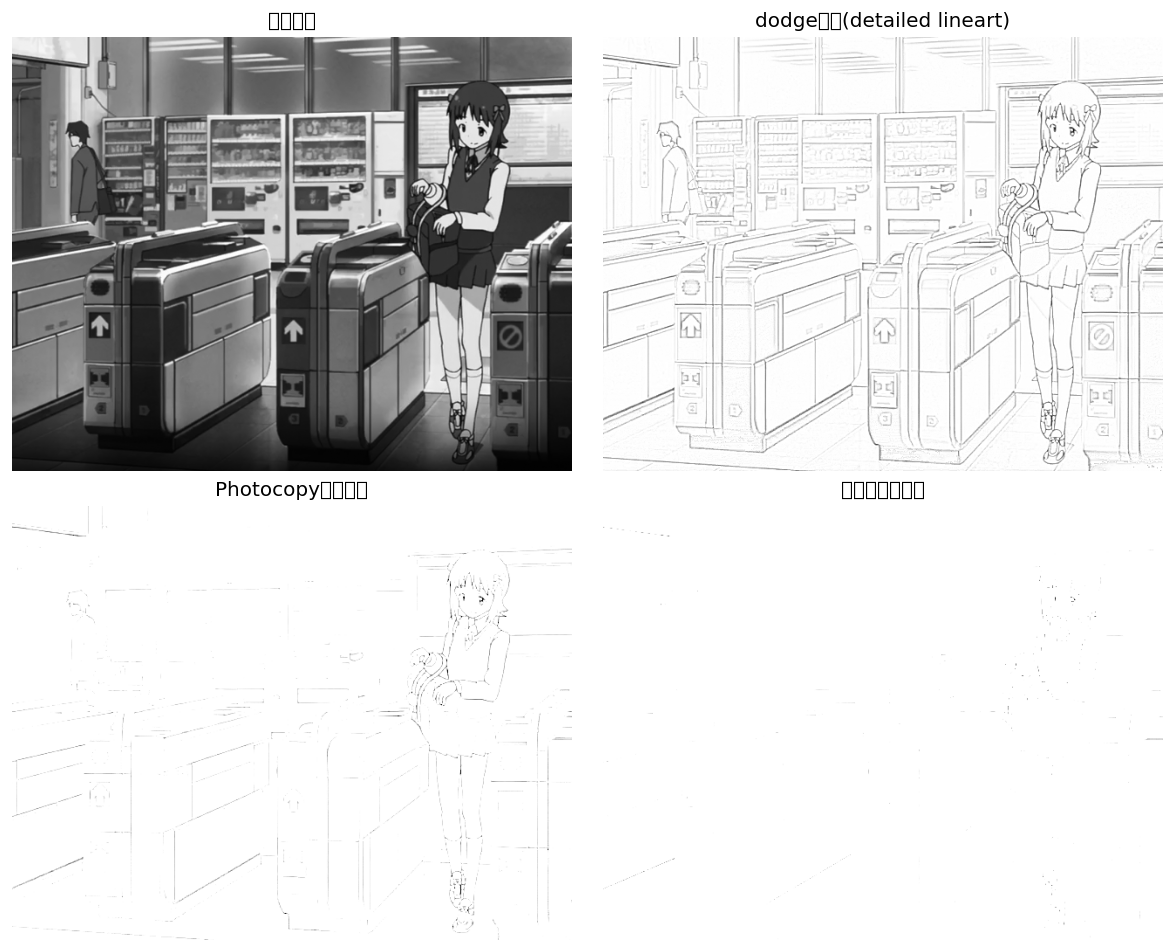

In [15]:

photocopy_gray, steps = photocopy_gray_lineart(
    image_path=image_path,
    detail=detail,
    darkness=darkness,
    gamma=gamma,
    soft_thr=soft_thr,
    soft_keep=soft_keep,
    contrast_alpha=contrast_alpha,
    contrast_beta=contrast_beta,
)

structure_line = thin_structure_line(
    photocopy_gray,
    method=thin_method,
    erode_kernel=erode_kernel,
    erode_iter=erode_iter,
)

cv2.imwrite(str(out_dir / "01_photocopy_gray.png"), photocopy_gray)
cv2.imwrite(str(out_dir / "02_structure_line.png"), structure_line)

show_images(
    [steps["gray"], steps["dodge"], photocopy_gray, structure_line],
    ["原始灰度", "dodge响应(detailed lineart)", "Photocopy灰度线稿", "细化后的结构线"],
    cols=2,
    figsize=(10, 8)
)



## 6. 读取 anime2sketch 结果

anime2sketch结果图路径:被变量 `anime_path`指向


/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 39118 (\N{CJK UNIFIED IDEOGRAPH-98CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 26684 (\N{CJK UNIFIED 

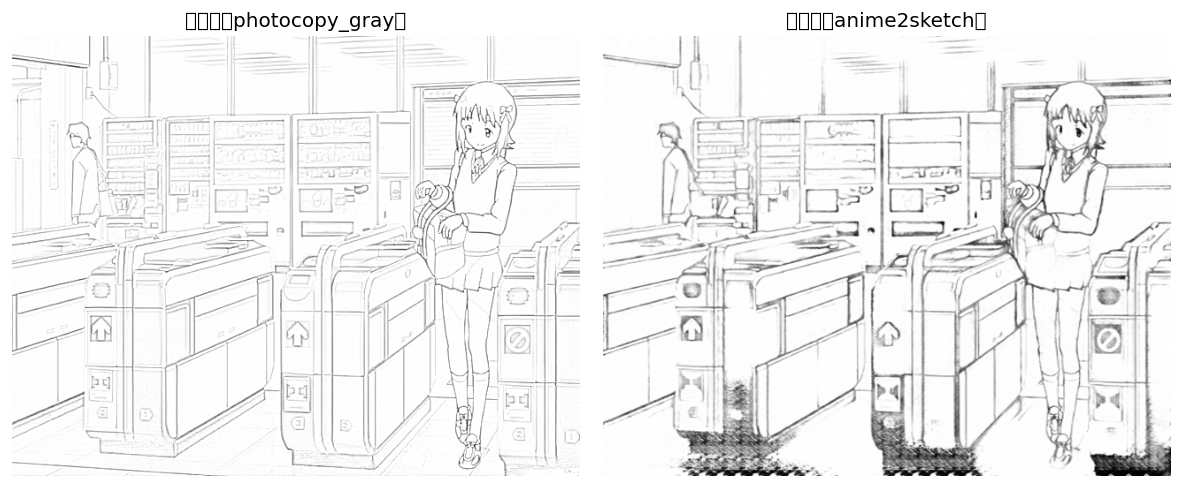

In [16]:
detailed_lines = steps["dodge"]
anime_gray = read_gray(anime_path)
anime_gray = make_blackline_whitebg(anime_gray)

cv2.imwrite(str(out_dir / "03_anime2sketch_gray.png"), anime_gray)

show_images(
    # [structure_line, anime_gray],
    [steps["dodge"], anime_gray],
    ["结构线（photocopy_gray）", "风格线（anime2sketch）"],
    cols=2,
    figsize=(10, 4)
)



## 7. 三种融合策略

### A. 透明度叠加
简单直观，但可能有轻微双线。

### B. 最小值融合（推荐）
因为线是黑色，所以取 `minimum` 可以自动保留更强的线，而不容易变粗。

### C. 结构 mask 融合（推荐）
用结构线约束 anime2sketch 的风格线，通常更干净。


In [13]:

def fuse_alpha_blend(structure, style, alpha=0.6, beta=0.4):
    structure_f = structure.astype(np.float32)
    style_f = style.astype(np.float32)
    fused = cv2.addWeighted(structure_f, alpha, style_f, beta, 0)
    return np.clip(fused, 0, 255).astype(np.uint8)

def fuse_minimum(structure, style):
    return np.minimum(structure, style)

def fuse_mask(structure, style, blur_ksize=3):
    """
    用结构线做mask约束风格线。
    输入要求：黑线白底
    """
    structure_f = structure.astype(np.float32) / 255.0
    style_f = style.astype(np.float32) / 255.0

    # 线区域 mask：线越黑，mask越强
    mask = 1.0 - structure_f
    if blur_ksize and blur_ksize > 1:
        k = blur_ksize if blur_ksize % 2 == 1 else blur_ksize + 1
        mask = cv2.GaussianBlur(mask, (k, k), 0)

    # 风格线受结构线约束
    # 背景保持白色，线区域引入style
    fused = 1.0 - (1.0 - style_f) * mask
    fused = np.clip(fused, 0, 1)
    return (fused * 255).astype(np.uint8)



## 8. 运行融合并比较结果


/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 26126 (\N{CJK UNIFIED IDEOGRAPH-660E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 21472 (\N{CJK UNIFIED I

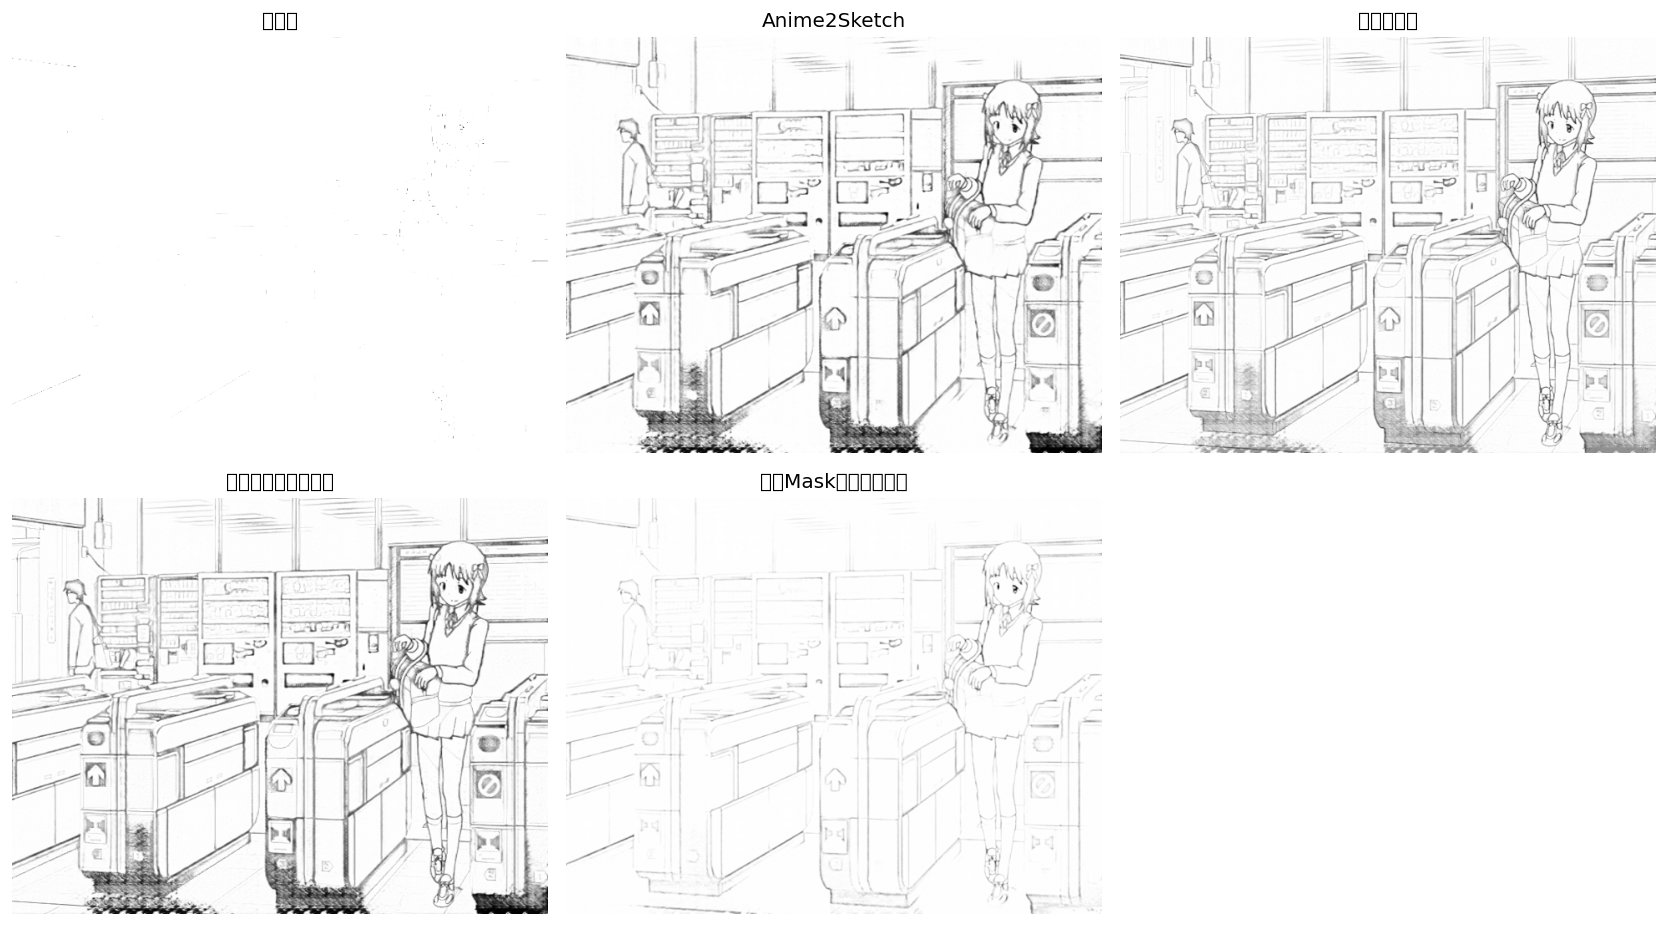

In [17]:

# fused_alpha = fuse_alpha_blend(structure_line, anime_gray, alpha=blend_alpha, beta=blend_beta)
# fused_min = fuse_minimum(structure_line, anime_gray)
# fused_mask = fuse_mask(structure_line, anime_gray, blur_ksize=mask_blur)

fused_alpha = fuse_alpha_blend(detailed_lines, anime_gray, alpha=blend_alpha, beta=blend_beta)
fused_min = fuse_minimum(detailed_lines, anime_gray)
fused_mask = fuse_mask(detailed_lines, anime_gray, blur_ksize=mask_blur)


cv2.imwrite(str(out_dir / "04_fused_alpha.png"), fused_alpha)
cv2.imwrite(str(out_dir / "05_fused_minimum.png"), fused_min)
cv2.imwrite(str(out_dir / "06_fused_mask.png"), fused_mask)

show_images(
    [structure_line, anime_gray, fused_alpha, fused_min, fused_mask],
    ["结构线", "Anime2Sketch", "透明度叠加", "最小值融合（推荐）", "结构Mask融合（推荐）"],
    cols=3,
    figsize=(14, 8)
)



## 9. 可选：把最终结果进一步变细，或者反转颜色

如果你最后要的是：
- **白线黑底**：用 `invert_output`
- **更细的黑线白底**：继续 `thin_structure_line`


/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 32456 (\N{CJK UNIFIED IDEOGRAPH-7EC8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_664814/2861160369.py:23: UserWarning: Glyph 26524 (\N{CJK UNIFIED I

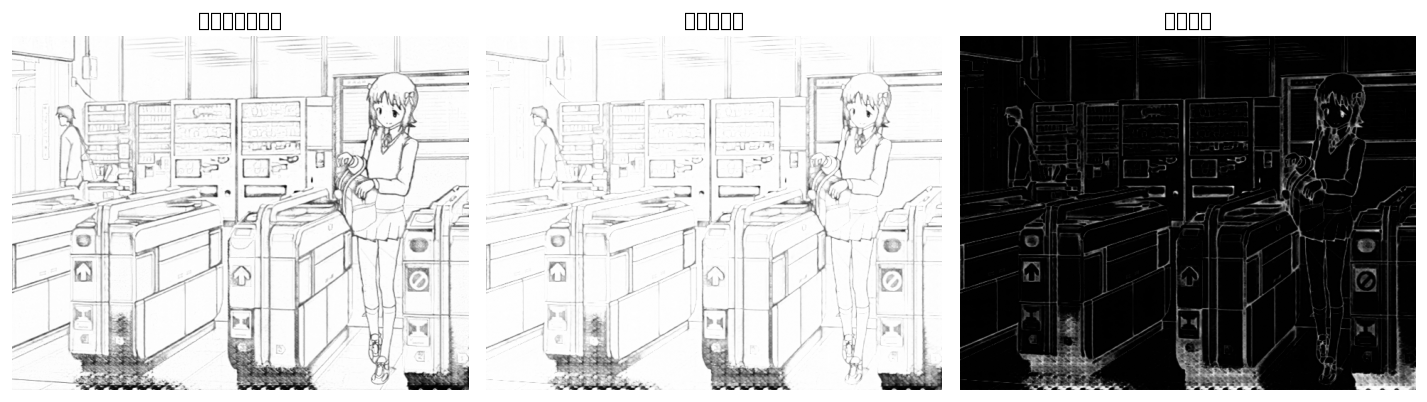

In [19]:

final_candidate = fused_min  # 可改成 fused_mask / fused_alpha

final_thin = thin_structure_line(final_candidate, method="erode", erode_kernel=2, erode_iter=1)
final_invert = invert_output(final_thin)

cv2.imwrite(str(out_dir / "07_final_thin.png"), final_thin)
cv2.imwrite(str(out_dir / "08_final_invert.png"), final_invert)

show_images(
    [final_candidate, final_thin, final_invert],
    ["选中的最终结果", "进一步细化", "反转颜色"],
    cols=3,
    figsize=(12, 4)
)



## 10. 调参建议

### Photocopy 侧
- `detail` 小一点（3~5）→ 保留更多细线  
- `gamma` 小一点（0.65~0.75）→ 强化细线  
- `soft_thr` 大一点（0.34~0.40）→ 去灰色区域更强  
- `contrast_beta` 更负（如 -25）→ 灰区更白

### 融合侧
- **优先试 `fused_min`**：通常最稳  
- `fused_mask` 更适合你想保留 anime2sketch 的“手绘感”，同时避免其偏离结构过多  
- `alpha blend` 只建议做快速预览

### 最终建议
对赛璐璐上色干净的图，通常推荐：
1. `Photocopy结构线`
2. `erode` 轻微细化
3. `Anime2Sketch`
4. `minimum fusion`
5. 必要时再反相
